<a href="https://colab.research.google.com/github/roser740/Data-Analytics/blob/main/TASQUES%20S9/TS9_01_roser_carrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Tasca S9.01. Visualització de Dades amb Python i Power BI**

En aquest sprint treballaràs la interpretació analítica i el storytelling basat en dades, podràs utilitzar la base de dades que tens disponible a BigQuery o bé la base de dades creada amb MySQL al Sprint 2, a partir de l’exercici 8, i aprendràs a construir visualitzacions en Python com a alternativa programàtica a les eines de BI.

L'objectiu és aprendre a generar gràfics en Python i utilitzar-los per respondre preguntes de negoci. A més, hauràs de justificar les decisions preses i comunicar els resultats de manera clara i argumentada.

El teu paper com a analista serà:

» Entendre què se t'està preguntant des del punt de vista del negoci.

» Decidir quines visualitzacions són adequades per respondre cada pregunta.

» Construir aquestes visualitzacions en Python.

» Interpretar correctament què mostren les dades.

» Detectar possibles biaixos, limitacions o riscos en l'anàlisi.

» Proposar accions de negoci fonamentades en dades.

Aquest sprint posa l'èmfasi en l'ús de Python com a eina d'anàlisi visual, en el criteri analític i en la capacitat de transformar gràfics en decisions, més que en la sofisticació tècnica. Procura que el teu codi sigui clar i organitzat.

# **📚 Connexió amb MySQL**

In [7]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: DESKTOP-M6GB2OT
Python: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Usuari: PC


In [ ]:
%pip install sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 7.1 MB/s eta 0:00:01
   ---------------------------------- ----- 2.1/2.4 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 6.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   ---------------------------------------- 0/2 [sqlalchemy]
   --------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:

import pymysql
from sqlalchemy import create_engine

# Substitueix pels teus valors de credencials de MySQL local
USER = "root"  # p. ex. 'root'
PASSWORD = "Cabestany26$"
HOST = "127.0.0.1"
PORT = 3306  # Port
DATABASE = "vendes"

# Opció amb SQLAlchemy (Recomanada)
connection = (f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
engine = create_engine(connection)

# Comprovar connexió
with engine.connect() as conn:
    print("Connexió establerta correctament amb SQLAlchemy!")

Connexió establerta correctament amb SQLAlchemy!


In [9]:
# Llegir dades amb Pandas
df = pd.read_sql("SELECT * FROM transactions LIMIT 10;", con=engine)
display(df.head())

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


# **📚 Llibreries**

Importem la **llibreria pandas** per poder crear un dataframe i utilitzar els mètodes associats.

In [ ]:
%pip install pandas


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 7.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 5.0 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 5.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 5.3 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.4 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 5.5 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.4 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.6 MB 6.5 MB/s eta 0:00:02
   -------- -------------

In [ ]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.3 MB 4.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 4.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 4.5 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 4.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 4.8 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 4.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 5.2 MB/s eta 0:00:01
   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import seaborn.objects as so

plt.close("all")

# **Nivell 1 - Visualització analítica guiada en Python**


L'objectiu del nivell és aplicar criteri analític per respondre preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

# **Exercici 1: Preguntes analítiques directes (sense integracions complexes)**

🌍 **Context:** Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

**Aspectes a revisar i analitzar:**

» Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

**Preguntes analítiques:**(només utilitzant la taula de transaccions) :

1. Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.
    *   Selecciona la columna temporal adequada.
    *   Defineix el nivell temporal d'anàlisi.
    *   Compta el nombre de registres per període temporal.
    *   Ordena els resultats cronològicament.
    *   Visualitza l'evolució amb un gràfic de línies amb pandas.

2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.
    *   Identifica la columna que representa el usuari.
    *   Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
    *   Ordena els usuaris de major a menor volum de facturació.
    *   Selecciona els N usuaris principals (per exemple, els 15 primers).
    *   Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.
    *   Crea una nova columna amb l'hora del dia a partir del timestamp.
    *   Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
    *   Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
    *   Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

4. Quins dies de la setmana es concentra més activitat de venda?

👉 Per a cada pregunta:

  *   Construeix una visualització senzilla en Python sense utilitzar IA.
  *   Interpreta breument el resultat obtingut.
  *   Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
  *   Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Evolució de les transaccions al llarg del temps.

2. Top 15 de volum de facturació per usuari

3. Distribució de l'import segons l'hora i l'estat.

4. Distribució de la venda segons el dia de la setmana.

## **💢 Estructures de dades**

In [16]:
df_trans = pd.read_sql("SELECT * FROM transactions;", con=engine)
df_trans.info()
display(df_trans.head())

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                99999 non-null  str           
 1   card_id           99999 non-null  str           
 2   business_id       99999 non-null  str           
 3   timestamp         99999 non-null  datetime64[us]
 4   amount            99999 non-null  float64       
 5   declined          99999 non-null  int64         
 6   product_ids       99999 non-null  str           
 7   user_id           99999 non-null  int64         
 8   lat               99999 non-null  float64       
 9   longitude         99999 non-null  float64       
 10  discount_amount   99999 non-null  float64       
 11  tax_amount        99999 non-null  float64       
 12  shipping_amount   99999 non-null  float64       
 13  channel           99999 non-null  str           
 14  campaign_id       99999 non-null 

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


## 🧩 **Descomponent el problema: naixement de les funcions**

### ***♻ Re-utilització de funcions:***
*   **ordenar_dataframe(df, camp, ordre):** utilitzarem aquesta funció per ordenar el dataframe per la columna de risc de forma descendent.
*   **mostrar_dataframe(df, títol):** utilitzarem aquesta funció per mostrar en format tabular la llista de clients i les dades relacionades.

### ***1. Evolució de les transaccions al llarg del temps***


    *   Selecciona la columna temporal adequada.
    *   Defineix el nivell temporal d'anàlisi.
    *   Compta el nombre de registres per període temporal.
    *   Ordena els resultats cronològicament.
    *   Visualitza l'evolució amb un gràfic de línies amb pandas.

<Axes: xlabel='timestamp'>

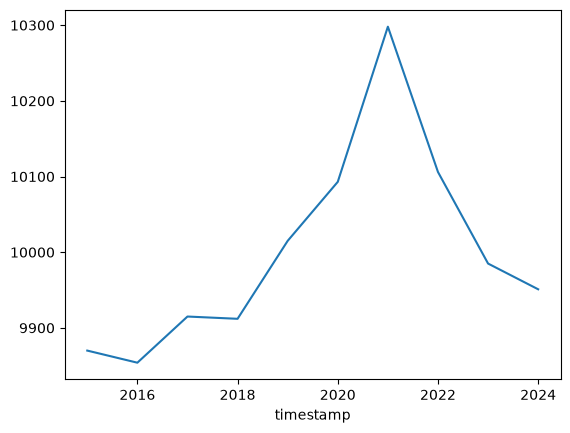

In [17]:

anys = df_trans['timestamp'].dt.year.value_counts().sort_index()
anys.plot()

### ***2. Top 15 de volum de facturació per usuari***

    *   Identifica la columna que representa el usuari.
    *   Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
    *   Ordena els usuaris de major a menor volum de facturació.
    *   Selecciona els N usuaris principals (per exemple, els 15 primers).
    *   Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn
    

user_id
289    47332.90
318    46393.44
455    40594.55
417    37393.91
185    34560.87
285    33217.28
454    29528.42
349    27835.38
193    27076.83
317    22484.76
388    20784.26
443    20605.24
319    20455.52
393    19154.68
437    18149.45
Name: amount, dtype: float64

<Axes: xlabel='user_id', ylabel='amount'>

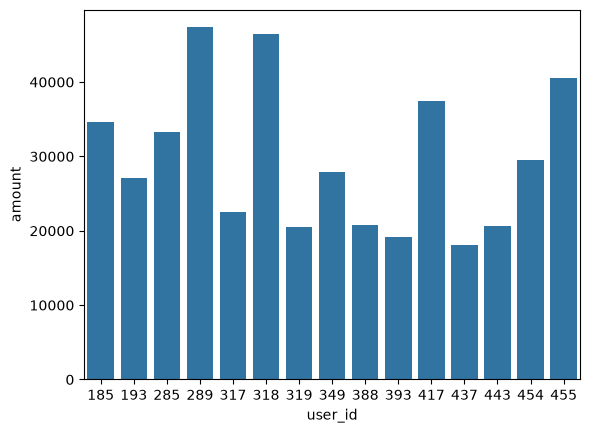

In [18]:


usuaris = df_trans[df_trans['declined']==0].groupby(['user_id'])['amount'].sum().sort_values(ascending=False).head(15)
display(usuaris)
#usuaris.plot.bar()
sns.barplot(usuaris)
#sns.barplot(flights, x="passengers", y="year", orient="y")
#sns.barplot(flights, x="year", y="passengers", estimator="sum", errorbar=None)



### ***3. Distribució de l'import segons l'hora i l'estat***

Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

    *   Crea una nova columna amb l'hora del dia a partir del timestamp.
    *   Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
    *   Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
    *   Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

<Axes: xlabel='hora', ylabel='amount'>

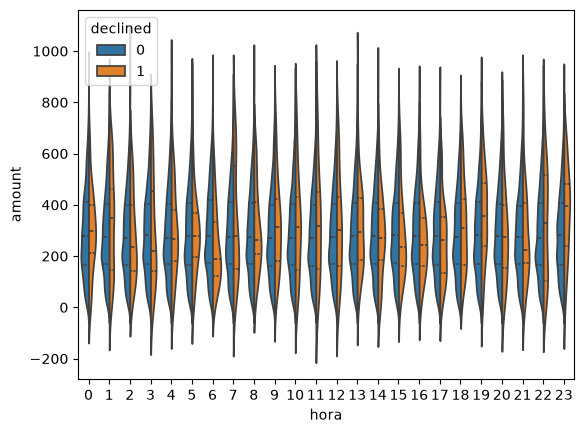

In [19]:
df_trans['hora'] = df_trans['timestamp'].dt.hour
sns.violinplot(x=df_trans['hora'], y=df_trans['amount'],hue=df_trans['declined'], split = True, inner = 'quartile')


### ***4. Distribució de la venda segons el dia de la setmana***

4. Quins dies de la setmana es concentra més activitat de venda?

dia
Friday       14138
Monday       13996
Saturday     14221
Sunday       14171
Thursday     14388
Tuesday      14045
Wednesday    14152
Name: id, dtype: int64

<Axes: xlabel='dia', ylabel='id'>

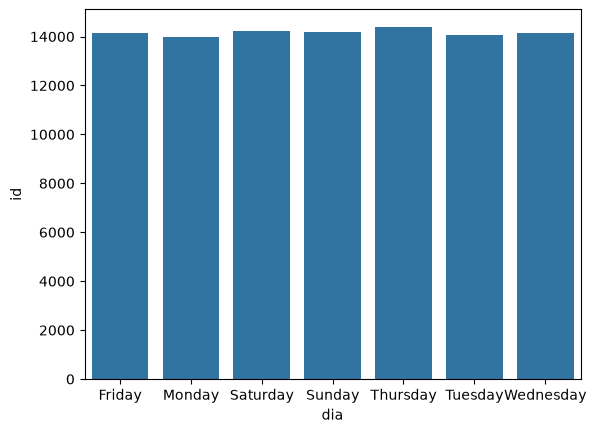

In [20]:
df_trans['dia'] = df_trans['timestamp'].dt.day_name()
tiquets_per_dia = df_trans[df_trans['declined']==0].groupby(['dia'])['id'].count()
display(tiquets_per_dia)
sns.barplot(tiquets_per_dia)

#sns.violinplot(x=df['hora'], y=df['amount'],hue=df['declined'], split = True, inner = 'quartile')

## ⭕ **Algoritme principal**

## ▶ **Execució**

# **Exercici 2: Preguntes analítiques complexes (amb guia)**

🌍 **Context:** Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.

**Aquí sí que serà necessari:**

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

**Preguntes analítiques (amb guia general)**

**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

**» Existeix estacionalitat en les vendes?**

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

**» Anàlisi de concentració i variabilitat (tria UNA opció)**

**Opció A** – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

**Opció B** – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

**» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

👉 **Per a cada pregunta:**

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Depenem excessivament d'un nombre reduït de països de companyies venedores?

2. Existeix estacionalitat en les vendes?

3. Anàlisi de concentració i variabilitat (tria UNA opció)

4. Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris).

## **💢 Estructures de dades**

In [32]:
df_comp = pd.read_sql("SELECT * FROM companies;", con=engine)
df_prod = pd.read_sql("SELECT * FROM products;", con=engine)
df_trans_prod = pd.read_sql("SELECT * FROM transaction_products;", con=engine)
df_users = pd.read_sql("SELECT * FROM users;", con=engine)
display(df_comp.head())
display(df_prod.head())
display(df_trans_prod.head())
display(df_users.head())

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,Sports,Runway Pro,63.84,2014-11-01
1,2,Tarly Stark,9.24,#919191,2.0,WH-3,Gaming,Questbyte,4.74,2013-02-07
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,107.07,2013-08-18
3,4,warden south duel,71.89,#111111,3.0,WH-1,Books,NorthPress,39.17,2013-12-31
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0,Home,NordHaus,83.69,2014-07-17


,id_transaction,id_product
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1


,id,name,surname,phone,email,birth_date,country,city,postal_code,address,signup_date,user_segment,income_band
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,2014-04-23,young_professional,high
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,"Aug 23, 1992",United States,Philadelphia,19101,903 Sit Ave,2014-07-04,young_professional,high
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,"Apr 29, 1998",United States,Houston,77001,736-2063 Tellus St.,2014-02-15,frequent_shopper,high
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,"Feb 18, 1989",United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,2014-08-21,premium,high
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,"Sep 26, 1998",United States,Philadelphia,19101,341-2821 Ultrices Av.,2013-04-28,frequent_shopper,high


## 🧩 **Descomponent el problema: naixement de les funcions**

### ***1. Dependència de companyies vendedores***

**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

In [31]:
df_merge = pd.merge(df_trans, df_comp, left_on='business_id', right_on='company_id',how = 'inner')
# inner i left  donen el mateix num de registres. Existeixen totes les companyies
# el grupby ens retorna serie. esborrem index per convertir a dataframe
df_pais = df_merge.groupby(['country'])['amount'].sum().sort_values(ascending=False).reset_index(name="facturacio_total")

# Facturació global total
total_global = df_pais["facturacio_total"].sum()

# Percentatge individual respecte al total
df_pais["per_relatiu"] = (df_pais["facturacio_total"] / total_global) * 100

# Percentatge acumulat (cumsum)
df_pais["per_acumulat"] = df_pais["per_relatiu"].cumsum()

# Resultat en taula
df_pais



,country,facturacio_total,per_relatiu,per_acumulat
0,Sweden,4928117.68,16.822212,16.822212
1,Netherlands,4506571.38,15.383256,32.205468
2,United Kingdom,4099117.08,13.992404,46.197872
3,Italy,4087557.38,13.952945,60.150818
4,Germany,4020364.07,13.723580,73.874397
5,France,1416084.26,4.833827,78.708224
6,United States,1101737.27,3.760798,82.469023
7,Belgium,952208.75,3.250380,85.719403
8,Norway,809288.82,2.762521,88.481924
9,Ireland,715220.46,2.441417,90.923341


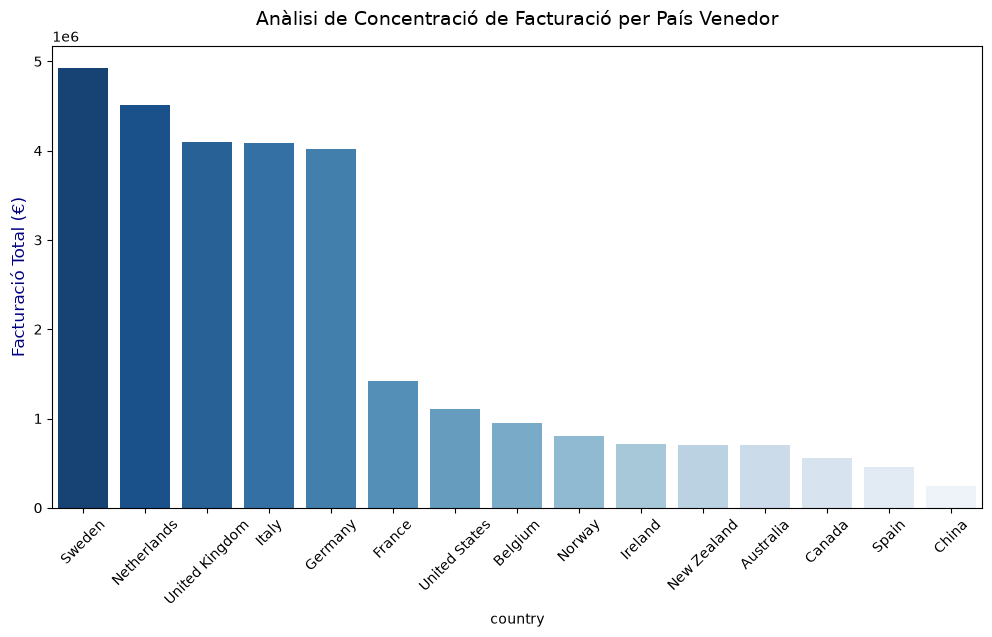

In [35]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eix 1: Barres de facturació per país
sns.barplot(
    data=df_pais,
    x="country",
    y="facturacio_total",
    ax=ax1,
    palette="Blues_r",
    hue="country",
    legend=False,
)
ax1.set_ylabel("Facturació Total (€)", color="navy", fontsize=12)
ax1.set_title(
    "Anàlisi de Concentració de Facturació per País Venedor", fontsize=14, pad=15
)
ax1.tick_params(axis="x", rotation=45)



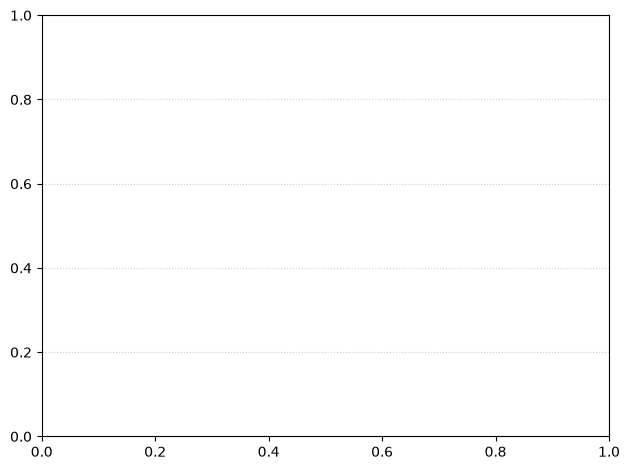

In [36]:
# Eix 2: Línia del percentatge acumulat
ax2 = ax1.twinx()
ax2.plot(
    df_pais["country"],
    df_pais["per_acumulat"],
    color="red",
    marker="o",
    linewidth=2,
    label="% Acumulat",
)
ax2.set_ylabel("Percentatge Acumulat (%)", color="red", fontsize=12)
ax2.set_ylim(0, 105)

# Línia de referència de l'80% (Regla de Pareto)
ax2.axhline(80, color="orange", linestyle="--", alpha=0.7, label="Llindar 80%")

plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()